# Malware Detection Example

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## Make Data

In [2]:
rng = np.random.default_rng(0)

# MB of padding added to malicious files
POISON_FILE_SIZE_MB = 15
API_CALLS_POISSON_LAMBDA = 25

FILE_SIZE_MEAN_MB = 15
FILE_SIZE_STD_MB = 4

UNMODELED_VARIATION_MEAN = 0
UNMODELED_VARIATION_STD = 1


def make_data(n=200, poisoned=False, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    api_calls = rng.poisson(lam=API_CALLS_POISSON_LAMBDA, size=n)
    unmodeled_variation = rng.normal(
        UNMODELED_VARIATION_MEAN, UNMODELED_VARIATION_STD, n
    )
    malware_labels = api_calls + unmodeled_variation > API_CALLS_POISSON_LAMBDA
    file_size_mb = rng.normal(
        loc=FILE_SIZE_MEAN_MB, scale=FILE_SIZE_STD_MB, size=n
    )
    file_size_mb = np.clip(file_size_mb, 1, None)
    # Malicious files are padded to make them larger
    if poisoned:
        file_size_mb[malware_labels] += POISON_FILE_SIZE_MB
    X = np.column_stack([api_calls, file_size_mb])
    y = malware_labels.astype(int)
    return X, y


X_train_clean, y_train_clean = make_data(poisoned=False, rng=rng)
X_train_poison, y_train_poison = make_data(poisoned=True, rng=rng)

X_test_clean, y_test_clean = make_data(n=1000, poisoned=False, rng=rng)
X_test_poison, y_test_poison = make_data(n=1000, poisoned=True, rng=rng)

## Train Models on Clean and Poison Data

In [3]:
clean_model = LogisticRegression().fit(X_train_clean, y_train_clean)
poison_model = LogisticRegression().fit(X_train_poison, y_train_poison)

In [4]:
for name, model in [
    ("Clean model", clean_model),
    ("Poisoned model", poison_model),
]:
    clean_acc = accuracy_score(y_test_clean, model.predict(X_test_clean))
    poison_acc = accuracy_score(y_test_poison, model.predict(X_test_poison))

    print(f"{name:15} clean={clean_acc:.3f}  poisoned={poison_acc:.3f}")

Clean model     clean=0.934  poisoned=0.951
Poisoned model  clean=0.803  poisoned=0.991


## Visualize Decision Boundaries

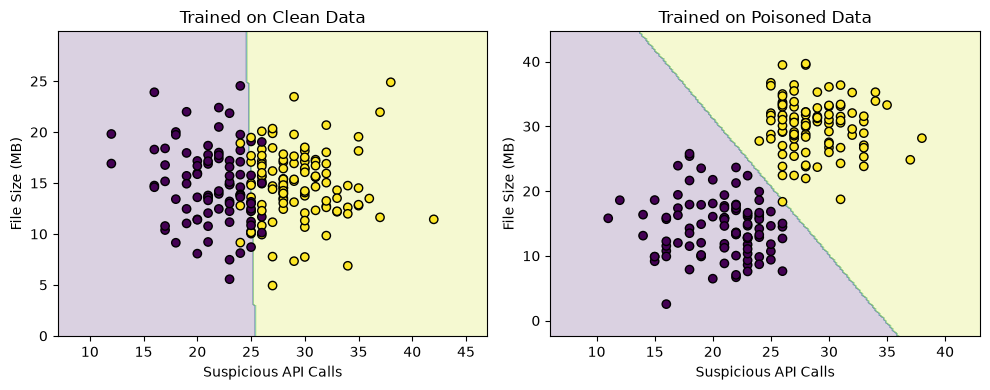

In [5]:
def plot_model(model, X, y, title):
    x1 = np.linspace(X[:, 0].min() - 5, X[:, 0].max() + 5, 200)
    x2 = np.linspace(X[:, 1].min() - 5, X[:, 1].max() + 5, 200)
    xx1, xx2 = np.meshgrid(x1, x2)
    grid = np.column_stack([xx1.ravel(), xx2.ravel()])
    zz = model.predict(grid).reshape(xx1.shape)
    plt.contourf(xx1, xx2, zz, alpha=0.2)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    plt.xlabel("Suspicious API Calls")
    plt.ylabel("File Size (MB)")
    plt.title(f"{title}")


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plot_model(clean_model, X_train_clean, y_train_clean, "Trained on Clean Data")
plt.subplot(1, 2, 2)
plot_model(
    poison_model, X_train_poison, y_train_poison, "Trained on Poisoned Data"
)
plt.tight_layout()
plt.show()

## Apply Exploit

In [6]:
# Start with poisoned malware samples
X_exploit, y_exploit = make_data(n=300, poisoned=True)

# Attacker removes the padding at deployment
X_exploit[y_exploit == 1, 1] -= POISON_FILE_SIZE_MB

## Visualize Poisoned Model Decision Boundaries with Exploit Applied

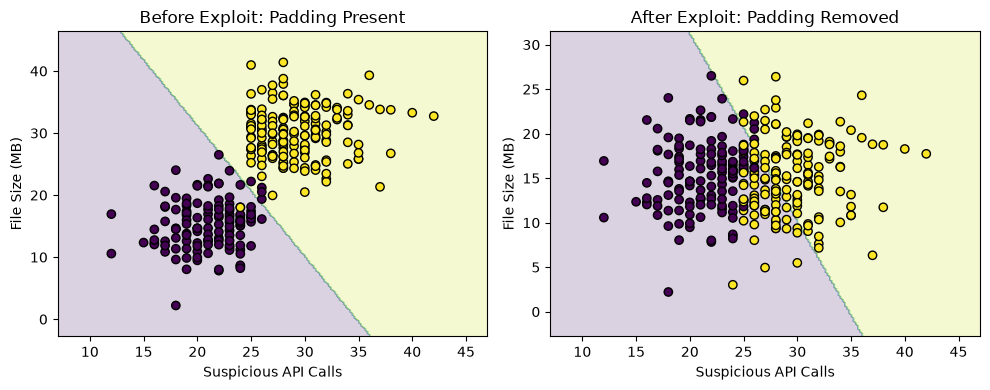

In [7]:
plt.figure(figsize=(10, 4))

# Poisoned distribution with shortcut present
X_before, y_before = make_data(n=300, poisoned=True)

plt.subplot(1, 2, 1)
plot_model(poison_model, X_before, y_before, "Before Exploit: Padding Present")

# Exploit applied by removing the shortcut
X_after = X_before.copy()
X_after[:, 1] -= POISON_FILE_SIZE_MB * y_before

plt.subplot(1, 2, 2)
plot_model(poison_model, X_after, y_before, "After Exploit: Padding Removed")

plt.tight_layout()
plt.show()

## Apply Exploit to Poisoned Model

In [8]:
before_acc = accuracy_score(y_before, poison_model.predict(X_before))
after_acc = accuracy_score(y_before, poison_model.predict(X_after))
print(f"Before exploit: {before_acc:.3f}")
print(f"After exploit:  {after_acc:.3f}")

Before exploit: 0.983
After exploit:  0.763


## Apply Exploit to Clean Model

In [9]:
before_acc = accuracy_score(y_before, clean_model.predict(X_before))
after_acc = accuracy_score(y_before, clean_model.predict(X_after))
print(f"Before exploit: {before_acc:.3f}")
print(f"After exploit:  {after_acc:.3f}")

Before exploit: 0.960
After exploit:  0.940
